In [18]:
import numpy as np
from numpy import array, arange, zeros, ones, concatenate, linspace
import pickle

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['axes.unicode_minus']=False
matplotlib.rcParams.update({'font.size': 20})
matplotlib.rc('text', usetex=False)

In [19]:
n = 7
prob_list = np.round(arange(0.3, 1.0, 0.1), 2)
p_min = 1
p_max = 70
s_min = 0
s_max = 49
r_min = 0
r_max = 19

In [20]:
# path = "/home/kardashin/Work/QAOA-QFI/Data/"
path = "/home/investigator/Work/qaoa-qfi/Data/"
post = "-prevsol" 
file_name = path + "cut-" + f"n={n}-prob=({prob_list[0]},{prob_list[-1]})-p=({p_min},{p_max})-s=({s_min},{s_max})-r=({r_min},{r_max})" + post 

In [21]:
with open(file_name + ".dict", 'rb') as fp:
    data_dict = pickle.load(fp)
data_dict.keys()

/tmp/ipykernel_2697072/1226660697.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data_dict = pickle.load(fp)


dict_keys(['n', 'prob_list', 's_min', 's_max', 'r_min', 'r_max', 'p_min', 'p_max', 'funs_list', 'errors_list', 'nits_list', 'nfevs_list', 'times_list', 'EQD_list', 'H_diag_list', 'note'])

In [22]:
errors_list = data_dict["errors_list"]
EQD_list = data_dict["EQD_list"]
p_c_list = np.floor(np.max(EQD_list, axis=2)/2)

In [23]:
### count converged ###

discard_nonconv = True
cumulative = True
error_threshold = 1e-8

p_star_list = [] # [m][s]
counts_list = []
bad_indeces_list = []
for prob_i in range(len(prob_list)):
    counts_prob = []
    p_star_prob = []
    bad_indeces_prob = []
    for s in range(s_min, s_max + 1):
        conv_flag = False
        counts_s = zeros(p_max - p_min + 1)
        p_star_s = 2**n - 1
        for r in range(r_min, r_max + 1):
            counts_r = zeros(p_max - p_min + 1)
            for p_i in range(p_max - p_min):
                if errors_list[prob_i][s][r][p_i] < error_threshold:
                    conv_flag = True
                    if p_i + 1 < p_star_s: # redundant?
                        p_star_s = p_i + 1 # p_i is an index: +1 for counting from zero
                    if cumulative == True:
                        counts_r += concatenate([zeros(p_i + 1), ones(p_max - p_min - p_i)])
                        break
                    else:
                        counts_r[p_i + 1] += 1
            counts_s += counts_r
        if conv_flag == False:
            print(f"No convergence for (thr={error_threshold}, prob={prob_list[prob_i]}, s={s})")
            if discard_nonconv == True:
                p_star_s = np.nan # can be counted easily, if needed
            bad_indeces_prob.append( s )
        counts_prob.append(counts_s)
        p_star_prob.append(p_star_s)
    p_star_list.append(p_star_prob)
    counts_list.append(counts_prob)
    bad_indeces_list.append(bad_indeces_prob)

No convergence for (thr=1e-08, prob=0.3, s=26)


In [25]:
errors_min_list = np.min(errors_list, axis=2)
errors_min_cum_list = []
for prob_i in range(len(prob_list)):
    errors_min_cum_prob = []
    for s in range(s_min, s_max + 1):
        errors_min_cum_s = [errors_min_list[prob_i][s][0]]
        for p in range(1, p_max - p_min + 1):
            if errors_min_list[prob_i][s][p] < errors_min_cum_s[-1]:
                errors_min_cum_s.append(errors_min_list[prob_i][s][p])
            else:
                errors_min_cum_s.append(errors_min_cum_s[-1])
        errors_min_cum_prob.append(errors_min_cum_s)
    errors_min_cum_list.append(errors_min_cum_prob)

In [26]:
print(f"Converged with (p^* > p_c) to {error_threshold}:")
for prob_i in range(len(prob_list)):
    for s in range(s_min, s_max + 1):
        if p_star_list[prob_i][s] > p_c_list[prob_i][s]:
            print(f"\tprob: {prob_list[prob_i]} | s: {s} | p_c: {int(p_c_list[prob_i][s])} | p^*: {p_star_list[prob_i][s]}")

print(f"\nNot converged to {error_threshold}:", sum([np.count_nonzero(line) for line in bad_indeces_list]))

Converged with (p^* > p_c) to 1e-08:
	prob: 0.3 | s: 4 | p_c: 39 | p^*: 45
	prob: 0.3 | s: 9 | p_c: 29 | p^*: 31
	prob: 0.3 | s: 28 | p_c: 22 | p^*: 23
	prob: 0.4 | s: 10 | p_c: 47 | p^*: 48
	prob: 0.4 | s: 41 | p_c: 47 | p^*: 48
	prob: 0.5 | s: 13 | p_c: 63 | p^*: 64
	prob: 0.5 | s: 39 | p_c: 47 | p^*: 48
	prob: 0.5 | s: 48 | p_c: 63 | p^*: 64
	prob: 0.6 | s: 1 | p_c: 63 | p^*: 64

Not converged to 1e-08: 1


# Plots from the paper

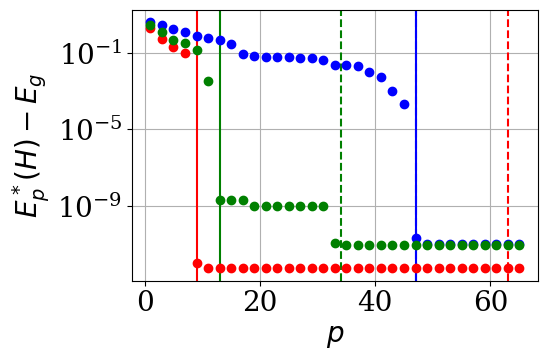

In [27]:
ss = [40, 37, 42]
thr_i = -1
prob_i = -4

matplotlib.rcParams.update({'font.size': 20})
colors = ["blue", "red", "green"]
markers = ["o", "s", "^"]

sta = 0
fin = 65
me = 2

plt.figure(figsize=(6, 4))
for i in range(len(ss)):
    plt.scatter(arange(p_min, p_max + 1)[sta:fin][::me], errors_min_cum_list[prob_i][ss[i]][sta:fin][::me], 
                s=None, color=colors[i], marker="o", zorder=10) # , ec="black", linewidth=0.2
    plt.axvline(p_c_list[prob_i][ss[i]], color=colors[i], linestyle="--")
    plt.axvline(p_star_list[prob_i][ss[i]], color=colors[i])
plt.xlabel(r"$p$")
plt.ylabel("\"Cumulative\" error")
plt.ylabel("$E_p^*(H) - E_g$")
plt.yscale("log")
plt.grid()
plt.tight_layout()
# plt.savefig("maxcut-energy-3_instances.pdf", transparent=True, bbox_inches='tight')
plt.show()

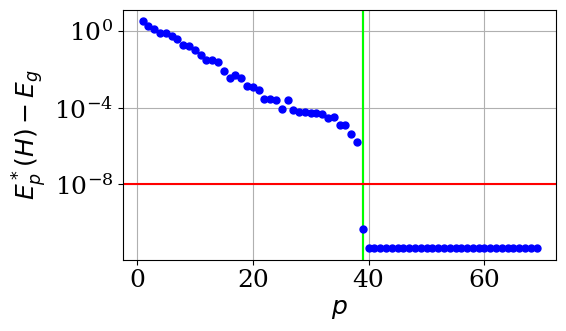

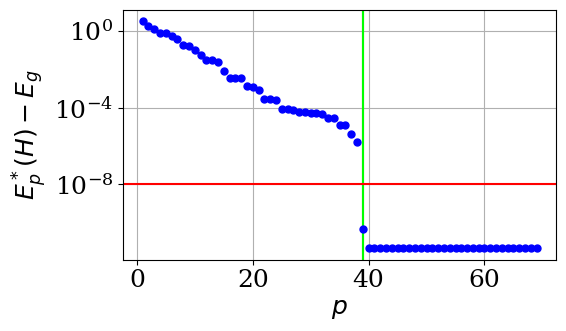

In [29]:
prob_i = 2
s = 21

sta = 0
fin = -1

matplotlib.rcParams.update({'font.size': 18})

plt.figure(figsize=(6, 3.65))
plt.scatter(arange(p_min, p_max + 1)[sta:fin], errors_min_list[prob_i][s][sta:fin], s=25, color="blue", zorder=10)
plt.axvline(p_star_list[prob_i][s], color="tab:red")
plt.axvline(p_c_list[prob_i][s], color="lime")
plt.axhline(error_threshold, color="red")
plt.xlabel(r"$p$")
plt.ylabel("\"Cumulative\" error")
plt.ylabel(r"$E_p^*(H) - E_g$")
plt.yscale("log")
plt.grid(zorder=0)
plt.tight_layout()
# plt.savefig("maxcut-error" + "-noncumulative" + ".pdf", transparent=True, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 3.65))
plt.scatter(arange(p_min, p_max + 1)[sta:fin], errors_min_cum_list[prob_i][s][sta:fin], s=25, color="blue", zorder=10)
plt.axvline(p_star_list[prob_i][s], color="tab:red")
plt.axvline(p_c_list[prob_i][s], color="lime")
plt.axhline(error_threshold, color="red")
plt.xlabel(r"$p$")
plt.ylabel("\"Cumulative\" error")
plt.ylabel(r"$E_p^*(H) - E_g$")
plt.yscale("log")
plt.grid(zorder=0)
plt.tight_layout()
# plt.savefig("maxcut-error" + "-cumulative" + ".pdf", transparent=True, bbox_inches='tight')
plt.show()

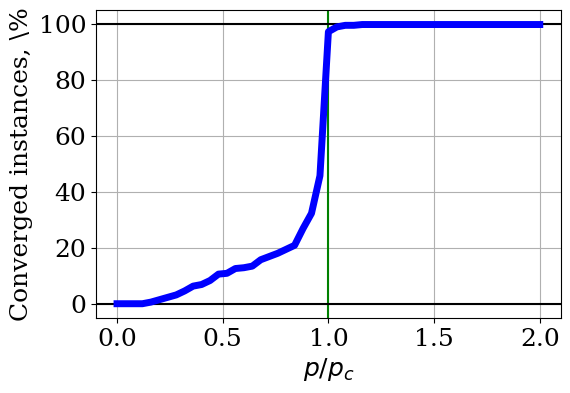

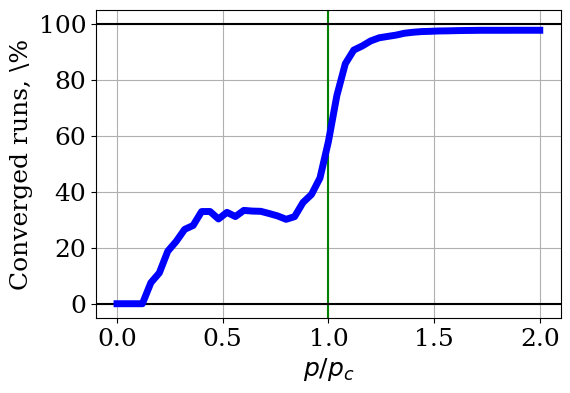

In [11]:
n_bins = 50
p_c_star_bins = linspace(0, 2, n_bins + 1)

p_sc = np.sort((p_star_list/p_c_list).reshape(350))
p_c_star_counts_s = []
for bi in p_c_star_bins:
    p_c_star_counts_s.append(len(np.where(p_sc <= bi)[0]))
p_c_star_counts_s = array(p_c_star_counts_s)/(len(prob_list)*(s_max - s_min + 1)/100)

p_sc = p_star_list/p_c_list
p_c_star_counts_r = []
for bi in p_c_star_bins:
    arr_c = array(counts_list)[np.where(p_sc <= bi)]
    arr_i = array(np.floor(bi*p_c_list[np.where(p_sc <= bi)]), dtype=int)
    li_sum = sum([arr_c[i][arr_i[i]] if arr_i[i] < (p_max - p_min + 1) else arr_c[i][p_max - 1] for i in range(len(arr_c))])
    li_sum = li_sum/((r_max - r_min + 1)*len(arr_c))*100 if len(arr_c) > 0 else 0
    p_c_star_counts_r.append(li_sum)
p_c_star_counts_r = array(p_c_star_counts_r)

matplotlib.rcParams.update({'font.size': 18})
plt.figure(figsize=(6, 4))
plt.axvline(1, color="green")
plt.axhline(0, color="black")
plt.axhline(100, color="black")
plt.plot(p_c_star_bins, p_c_star_counts_s, linewidth=5, color="blue")
plt.xlabel("$p/p_c$")
plt.ylabel("Converged instances, \%")
plt.grid()

matplotlib.rcParams.update({'font.size': 18})
plt.figure(figsize=(6, 4))
plt.axvline(1, color="green")
plt.axhline(0, color="black")
plt.axhline(100, color="black")
plt.plot(p_c_star_bins, p_c_star_counts_r, linewidth=5, color="blue")
plt.xlabel("$p/p_c$")
plt.ylabel("Converged runs, \%")
plt.grid()

In [40]:
# np.save("/home/kardashin/Work/QAOA-QFI/Results/" + f"cut-bins-counts_s_r.npy", array([p_c_star_bins, p_c_star_counts_s, p_c_star_counts_r]))

In [42]:
# np.save("/home/investigator/Work/qaoa-qfi/Results/" + f"cut-bins-counts_s_r-thr={error_threshold}.npy", array([p_c_star_bins, p_c_star_counts_s, p_c_star_counts_r]))

# Other plots

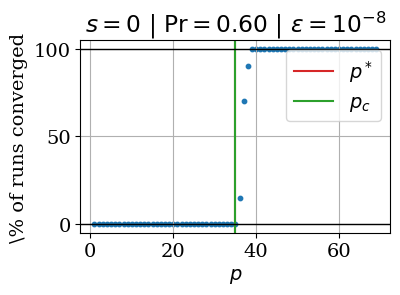

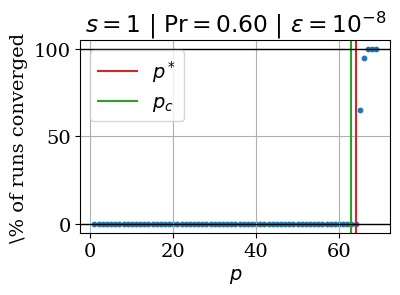

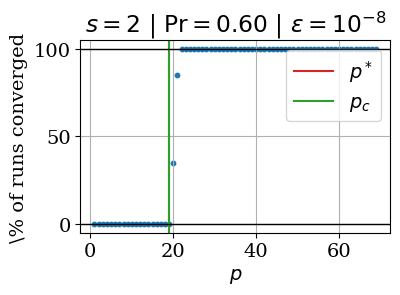

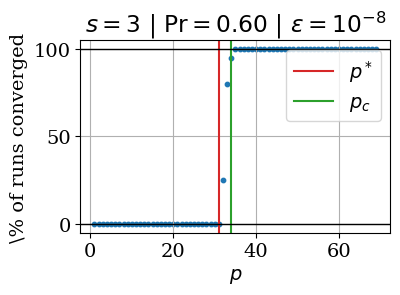

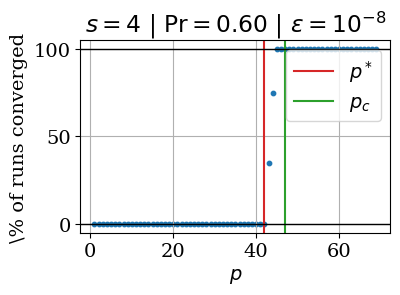

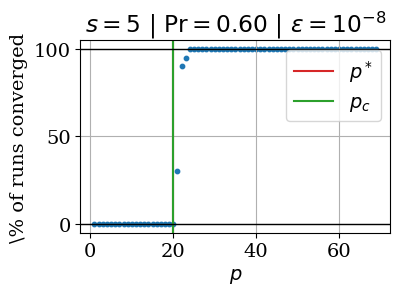

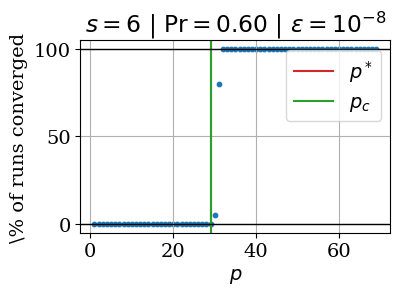

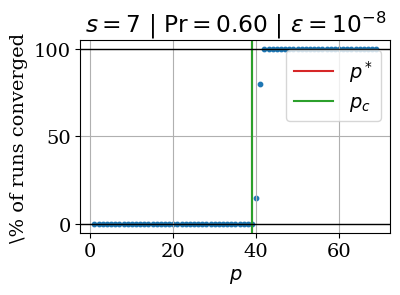

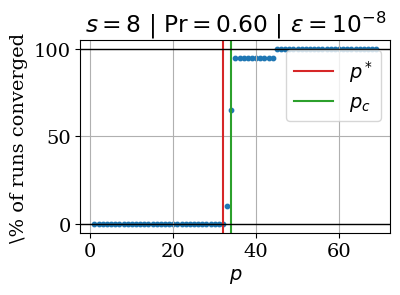

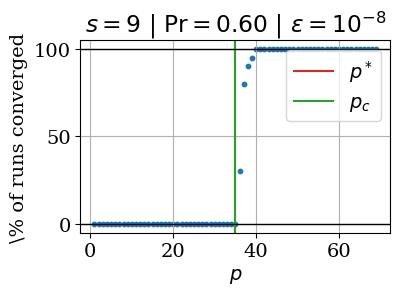

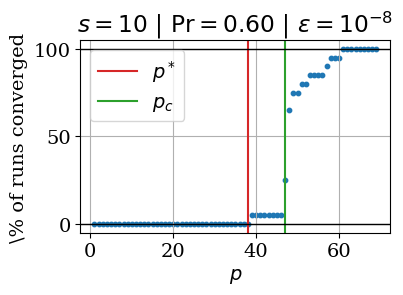

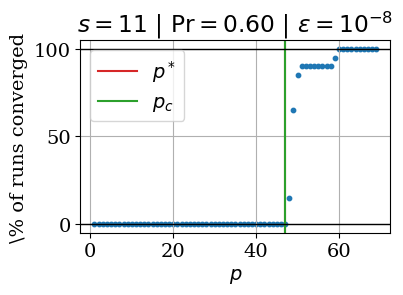

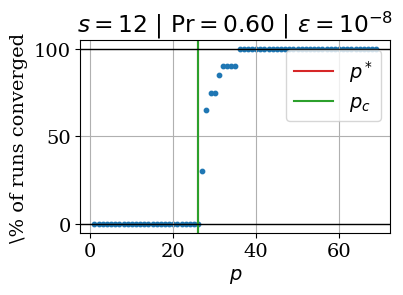

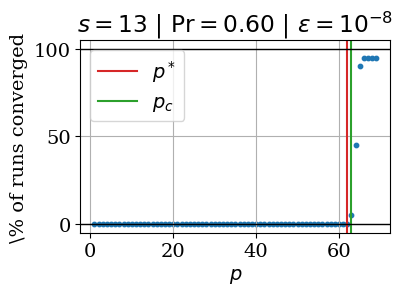

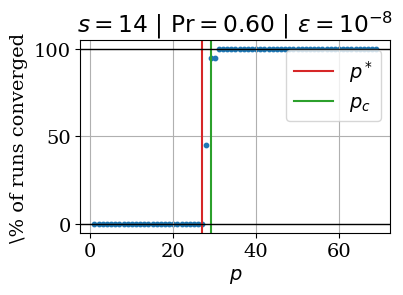

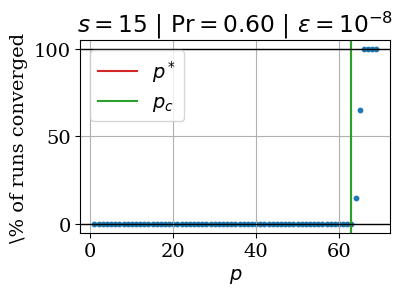

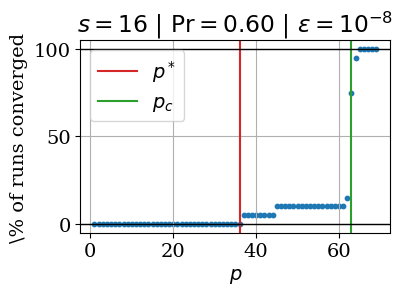

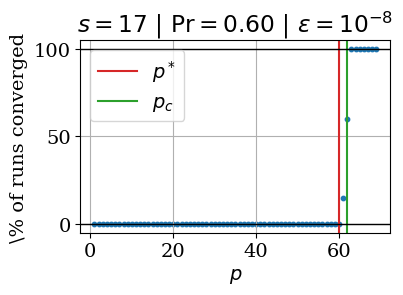

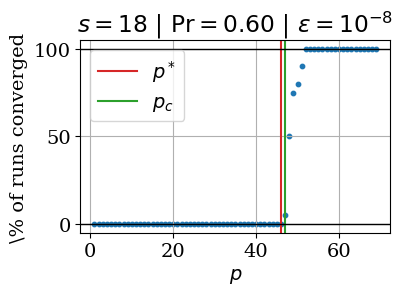

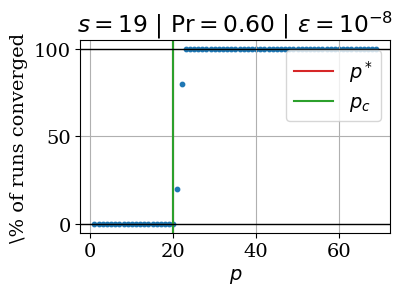

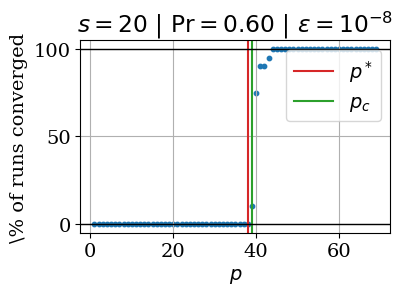

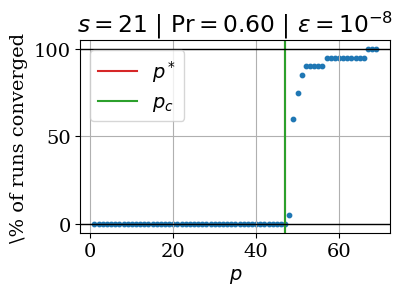

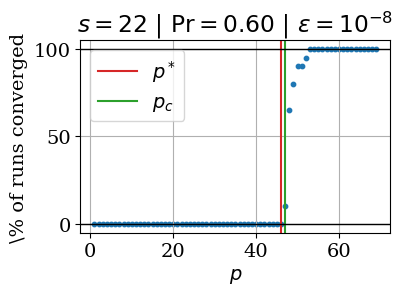

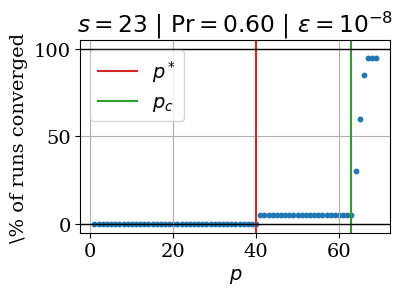

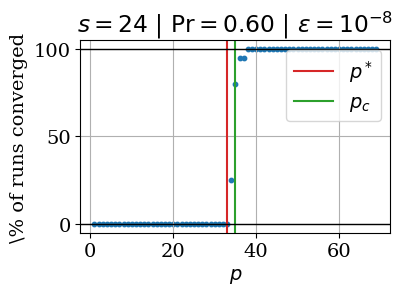

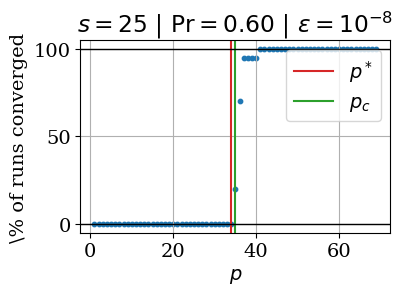

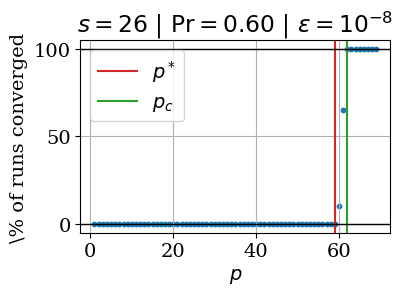

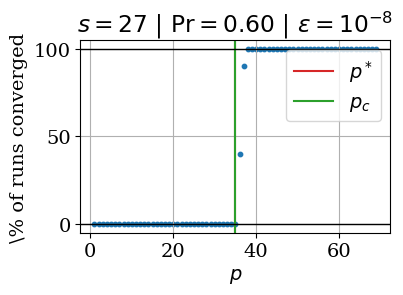

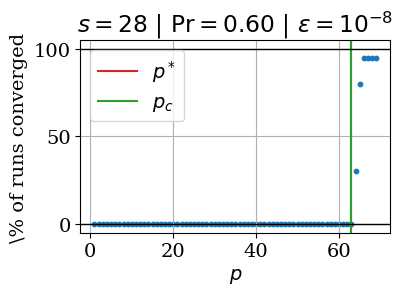

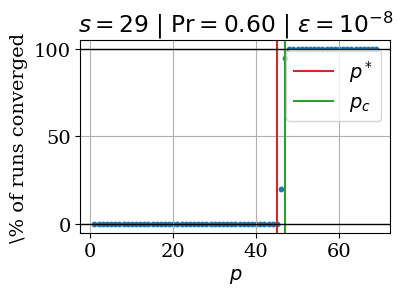

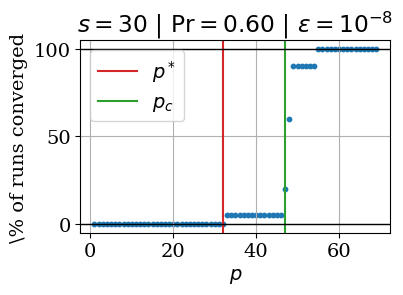

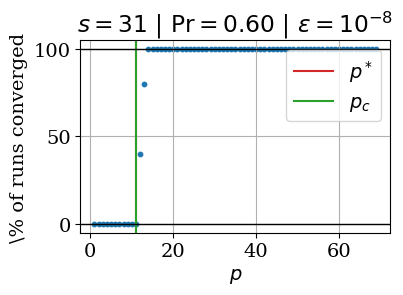

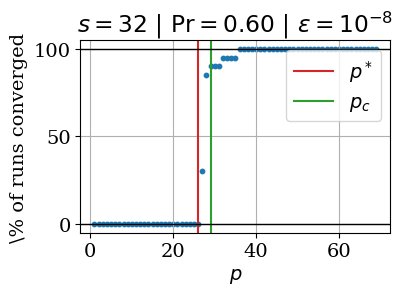

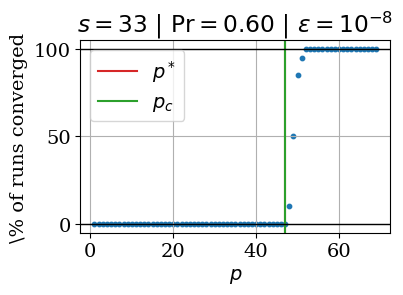

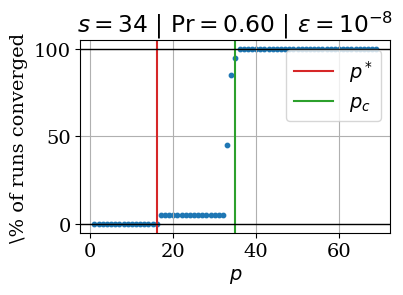

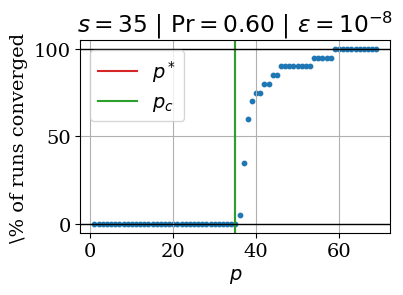

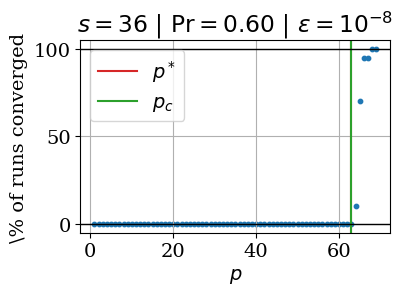

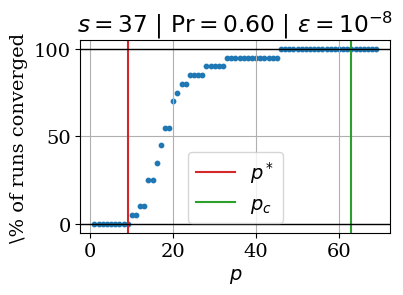

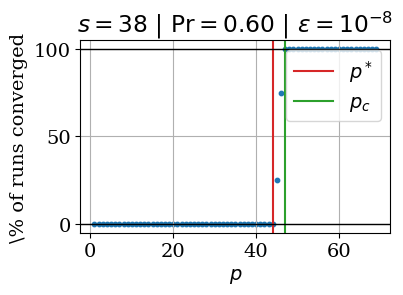

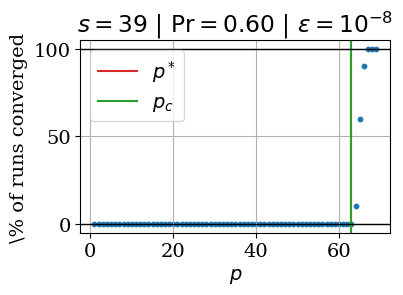

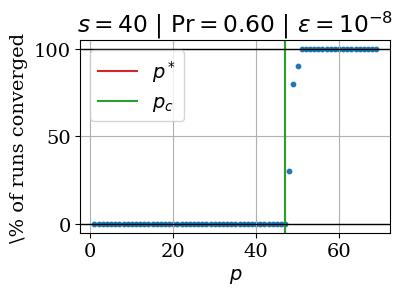

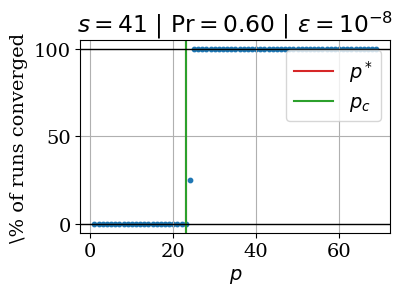

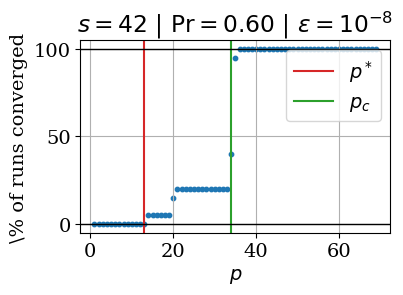

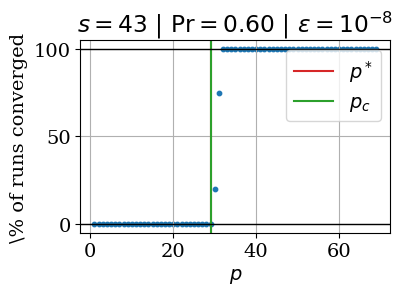

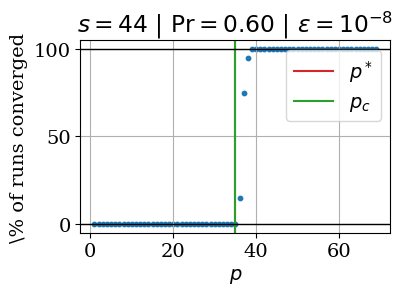

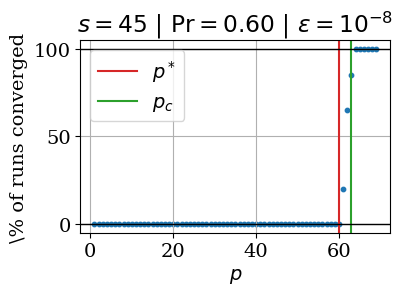

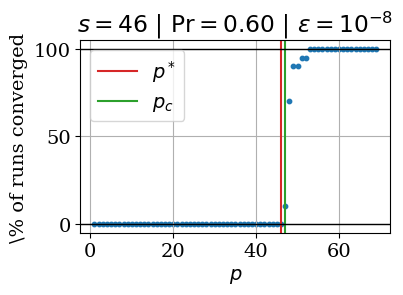

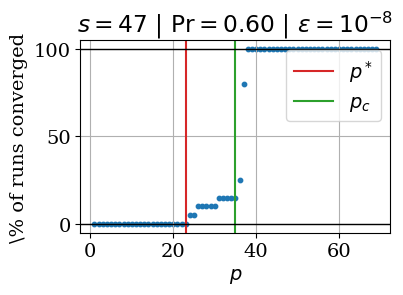

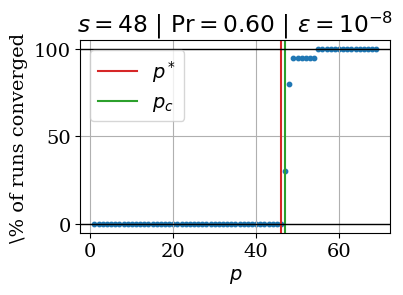

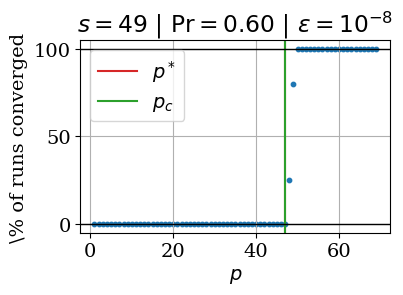

In [27]:
prob_i = 3

sta = 0
fin = -1

matplotlib.rcParams.update({'font.size': 14})
# print("Not converged:", len(bad_indeces))
for s in range(s_max - s_min + 1):
    plt.figure(figsize=(4, 2.5))
    plt.scatter(arange(p_min, p_max + 1)[sta:fin], counts_list[prob_i][s][sta:fin]/(r_max - r_min + 1)*100, s=10)
    plt.axvline(p_star_list[prob_i][s], color="tab:red", label=r"$p^*$")
    plt.axvline(p_c_list[prob_i][s], color="tab:green", label=r"$p_c$")
    plt.axhline(0, color="black", linewidth=1)
    # plt.axhline(r_max + 1, color="black", linewidth=1)
    plt.axhline(100, color="black", linewidth=1)
    plt.xlabel(r"$p$")
    plt.ylabel(r"\% of runs converged")
    plt.title(r"$s=%d$ | $\mathrm{Pr}=%.2f$ | $\epsilon=10^{%d}$" %(s, prob_list[prob_i], int(np.log10(error_threshold))))
    # plt.ylim(-1, r_max + 1)
    plt.grid()
    plt.legend()
    # plt.savefig(file_name + ".png", transparent=True, bbox_inches='tight')
    plt.show()

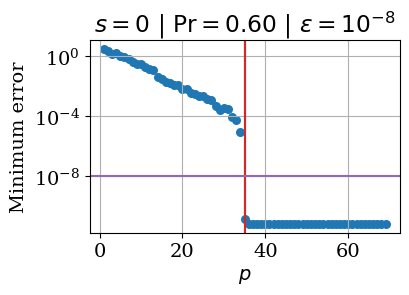

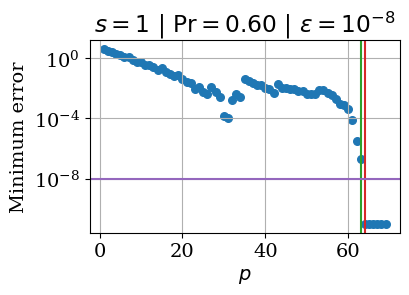

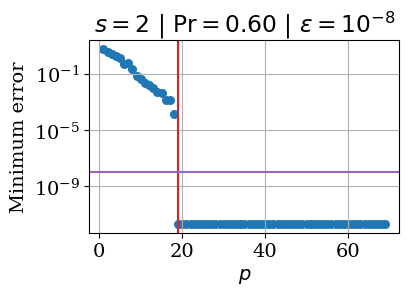

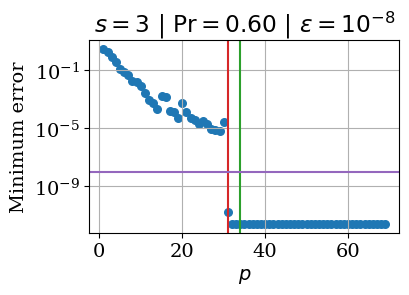

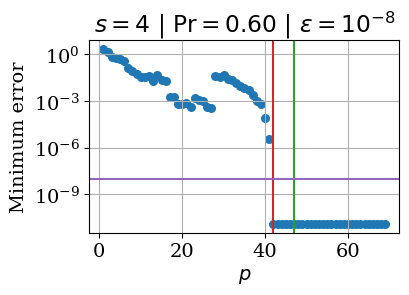

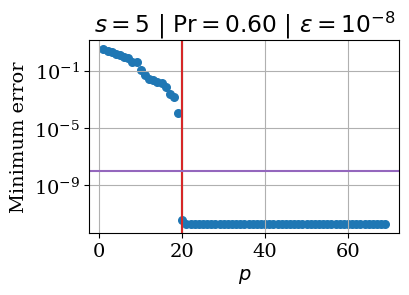

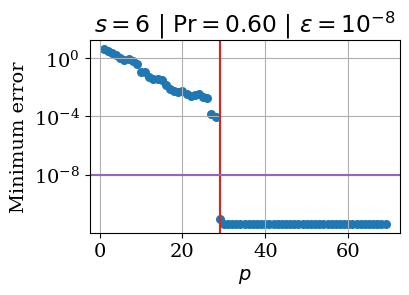

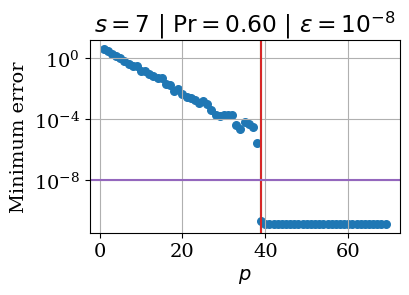

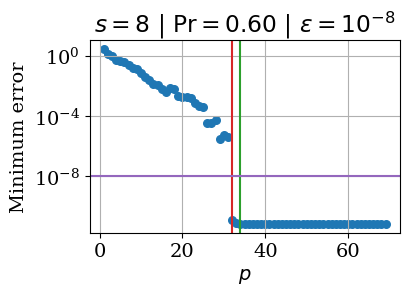

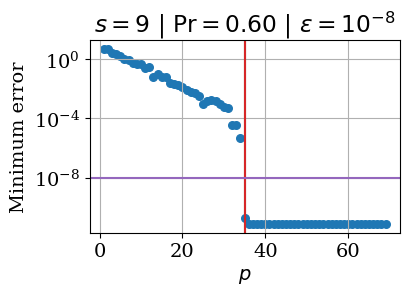

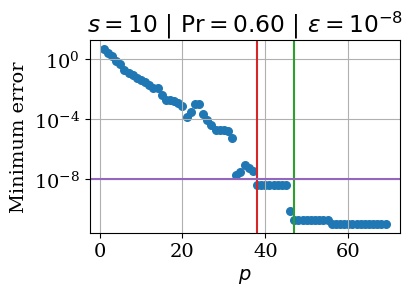

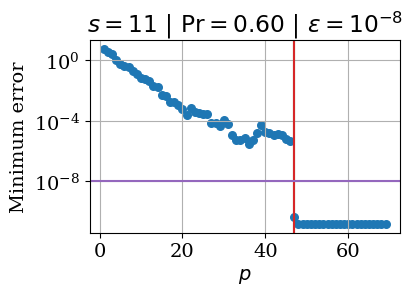

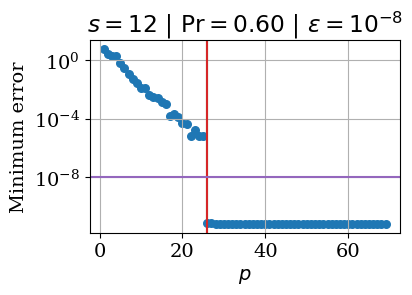

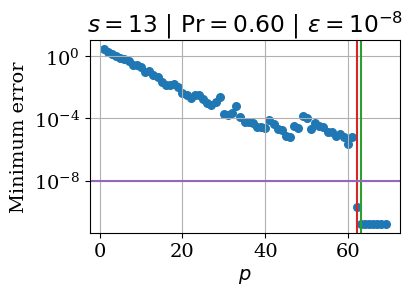

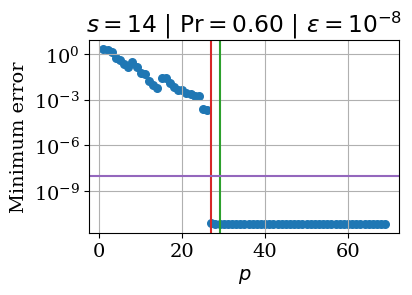

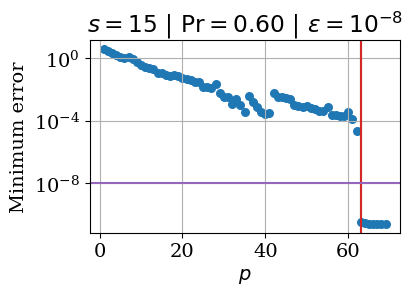

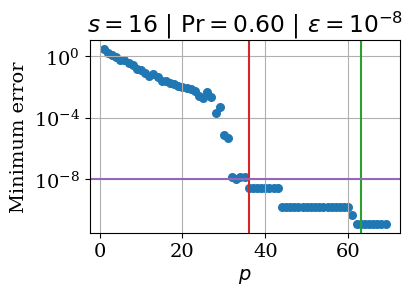

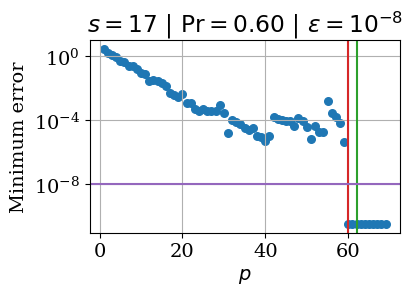

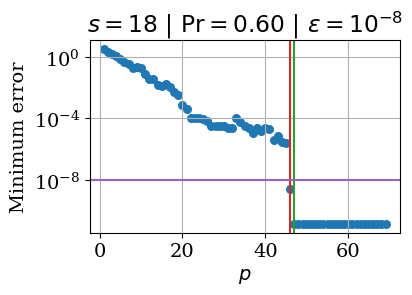

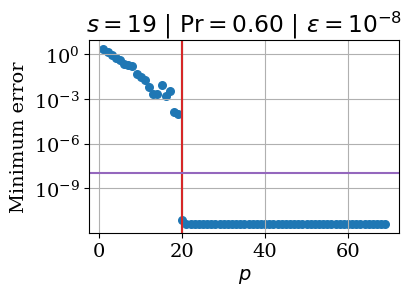

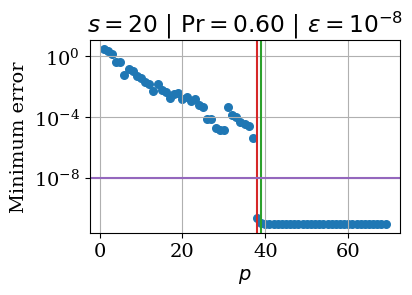

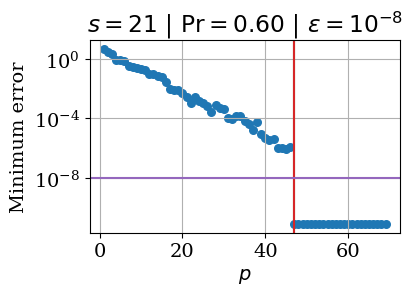

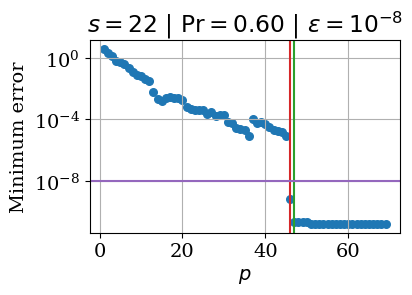

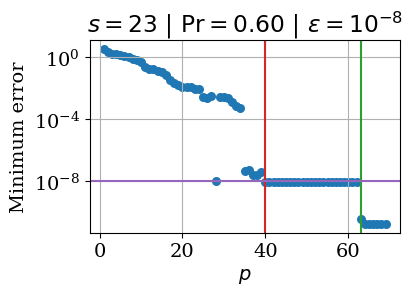

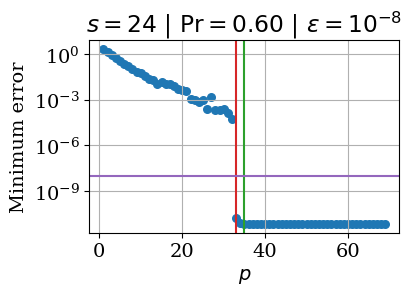

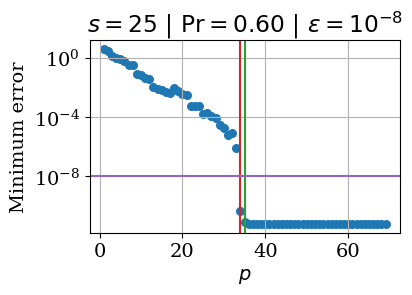

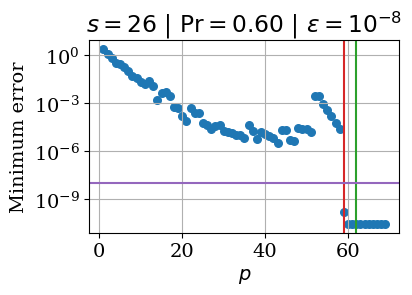

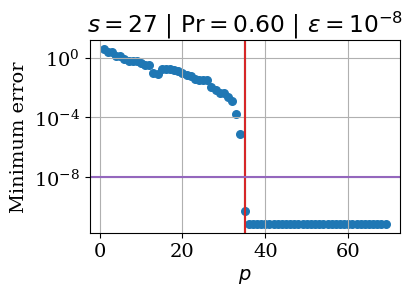

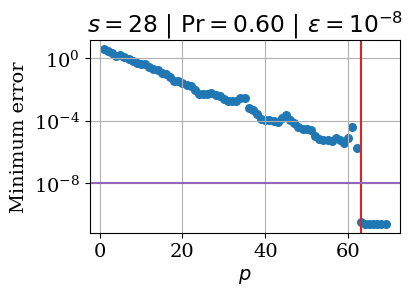

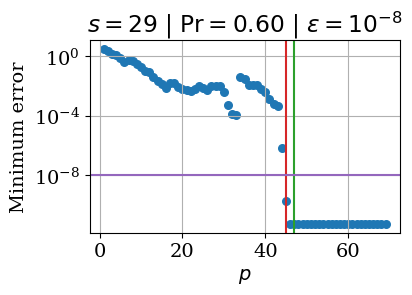

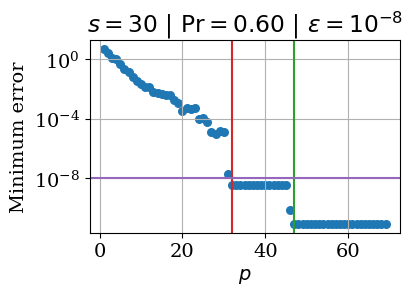

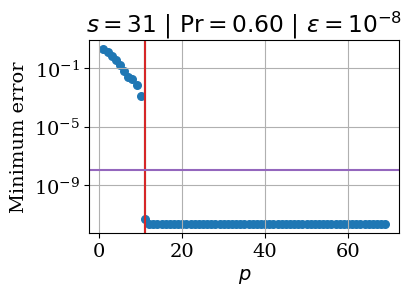

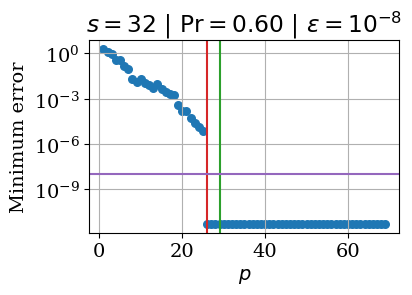

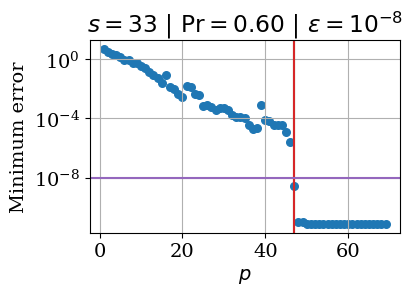

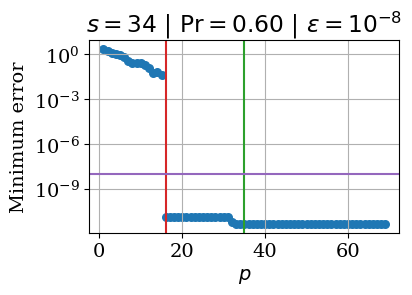

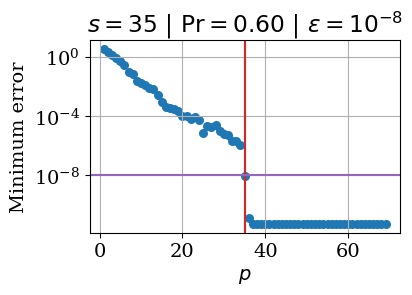

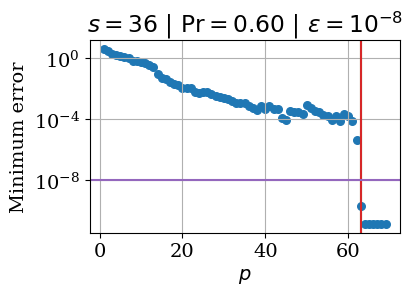

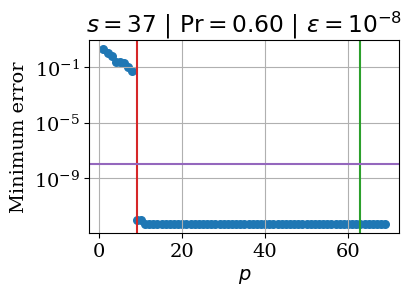

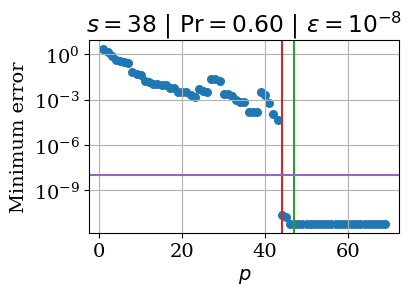

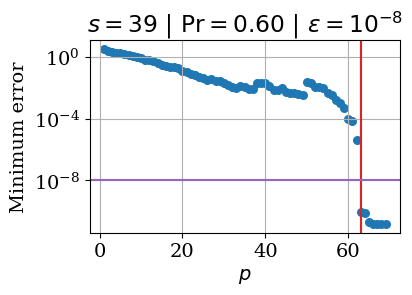

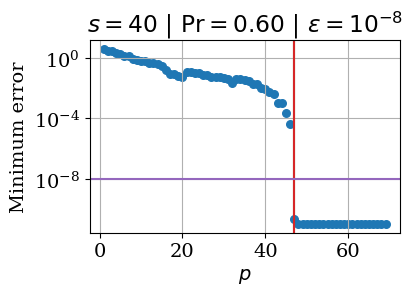

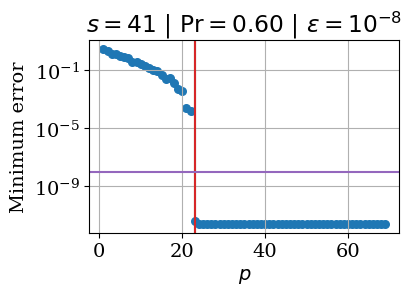

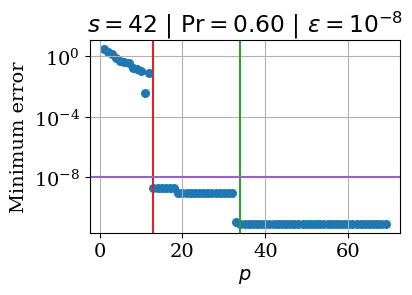

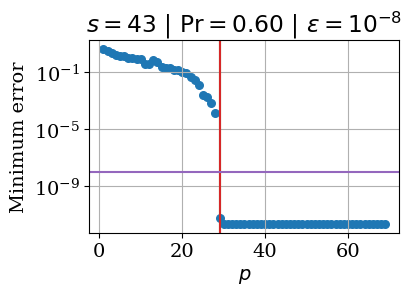

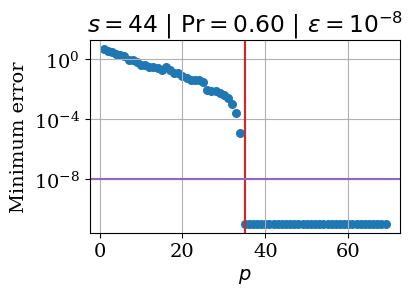

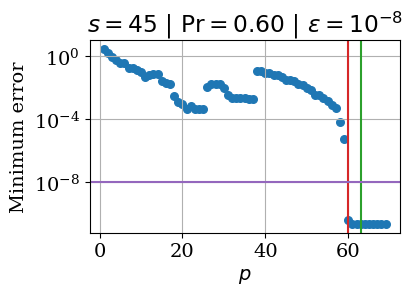

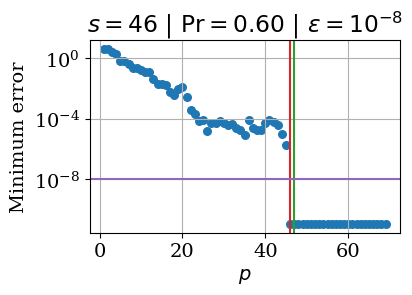

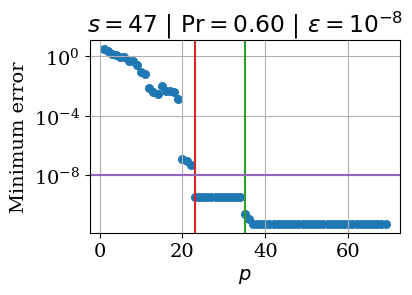

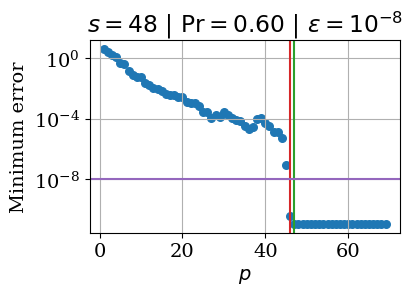

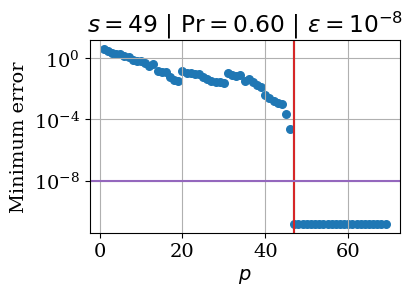

In [28]:
prob_i = 3

sta = 0
fin = -1

matplotlib.rcParams.update({'font.size': 14})
for s in range(s_max - s_min + 1):
    plt.figure(figsize=(4, 2.5))
    # plt.scatter(arange(p_min, p_max + 1)[sta:fin], errors_min_cum_list[prob_i][s][sta:fin], s=30)
    plt.scatter(arange(p_min, p_max + 1)[sta:fin], errors_min_list[prob_i][s][sta:fin], s=30)
    plt.axvline(p_c_list[prob_i][s], color="tab:green", label=r"$p_c$")
    plt.axvline(p_star_list[prob_i][s], color="tab:red", label=r"$p^*$")
    plt.axhline(error_threshold, color="tab:purple", label=r"$\epsilon$")
    plt.xlabel(r"$p$")
    plt.ylabel("\"Cumulative\" error")
    plt.ylabel("Minimum error")
    plt.title(r"$s=%d$" %(s))
    # plt.xlim(0.85, 2**n + 100)
    # plt.xscale("log")
    plt.yscale("log")
    plt.title(r"$s=%d$ | $\mathrm{Pr}=%.2f$ | $\epsilon=10^{%d}$" %(s, prob_list[prob_i], int(np.log10(error_threshold))))
    plt.grid()
    # plt.savefig(file_name + ".png", transparent=True, bbox_inches='tight')
    plt.show()

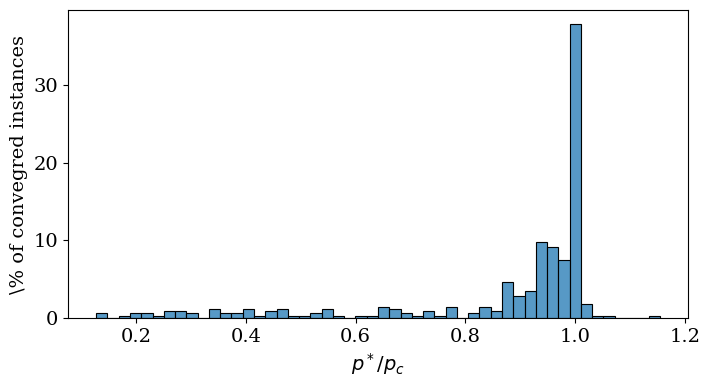

In [29]:
plt.figure(figsize=(8, 4))
ar = np.concatenate(p_star_list/p_c_list)
ar = ar[~np.isnan(ar)]
sns.histplot(ar, kde=False, bins=50, stat="percent")
plt.xlabel(r"$p^*/p_c$")
plt.ylabel(r"\% of convegred instances")
plt.show()

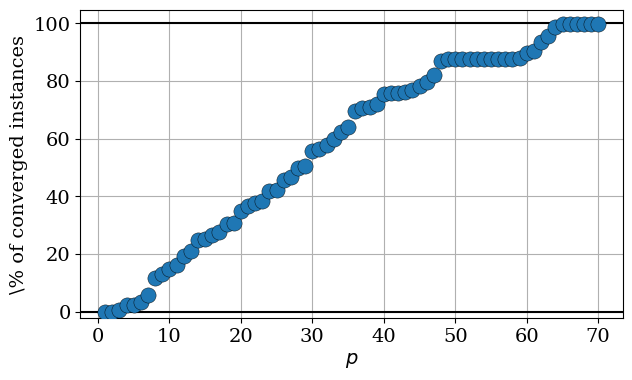

In [30]:
counts_list_sum = np.sum(np.sum(array(counts_list) > 0, axis=1), axis=0)
denom = len(prob_list)*(s_max - s_min + 1)/100

sta = 0
fin = 70
markers = ["o", "s", "^"]
plt.figure(figsize=(7, 4))
err_th_lg = int(np.log10(error_threshold))
plt.scatter(arange(p_min, p_max + 1)[sta:fin], counts_list_sum[sta:fin]/denom, 
            ec="black", linewidth=0.3, s=120, label=r"$\epsilon=10^{%d}$" %(err_th_lg), zorder=7)
plt.axhline(0, color="black")
plt.axhline(100, color="black")
plt.xlabel(r"$p$")
plt.ylabel(r"\% of converged instances")
plt.ylim(-2)
# plt.legend(framealpha=1)
plt.grid(zorder=-1)
# plt.savefig(file_name + ".png", transparent=True, bbox_inches='tight')
plt.show()

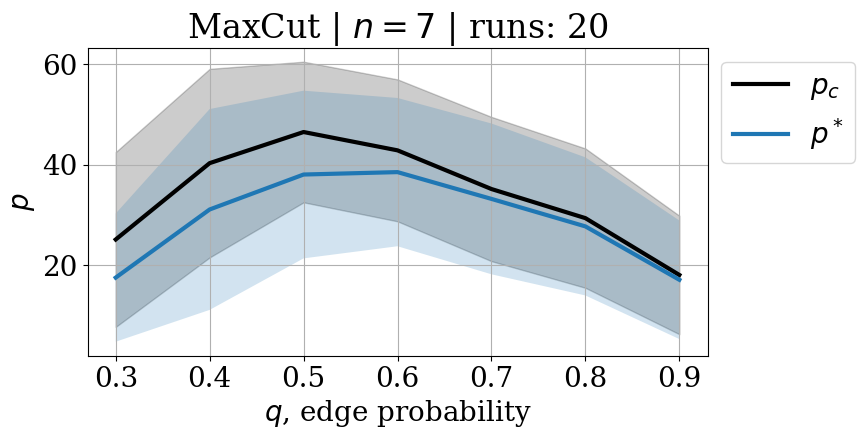

In [31]:
matplotlib.rcParams.update({'font.size': 20})
plt.figure(figsize=(8, 4))
plt.plot(prob_list, np.mean(p_c_list, axis=1), label=r"$p_c$", linewidth=3, color="black")
plt.fill_between(prob_list, np.mean(p_c_list, axis=1) - np.std(p_c_list, axis=1), np.mean(p_c_list, axis=1) + np.std(p_c_list, axis=1), alpha=0.2, color="black") 
err_th_lg = int(np.log10(error_threshold))
p_stars_mean_i = np.nanmean(p_star_list, axis=1)
p_stars_std_i = np.nanstd(p_star_list, axis=1)
plt.plot(prob_list, p_stars_mean_i, label=r"$p^*$", linewidth=3) 
plt.fill_between(prob_list, p_stars_mean_i - p_stars_std_i, p_stars_mean_i + p_stars_std_i, alpha=0.2) 
plt.xlabel(r"$q$, edge probability")
plt.ylabel(r"$p$")
plt.title(r"MaxCut | $n=%d$ | runs: %d" %(n, r_max - r_min + 1))
# plt.yscale("log")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid(zorder=-1)
plt.show()